# 10 — Final Evaluation

**BBL514E Pattern Recognition — Term Project (MVP)**

Tüm stage'lerin ve pipeline'ın test set üzerindeki final değerlendirmesi.
Bu notebook, final raporun **Results** bölümü için hazır tablolar ve grafikler üretir.

## içerik
1. Stage 1 vs Stage 3 metrik tablo
2. Confusion matrix grid (Stage 1 LDA, Stage 1 MLP, Stage 3 LDA, Stage 3 MLP)
3. ROC curves (one-vs-rest, her sınıf için)
4. Stage-wise comparison
5. Backtest summary referansı

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import (
    roc_curve, auc, confusion_matrix,
    classification_report, accuracy_score, f1_score,
)
from sklearn.preprocessing import label_binarize

plt.style.use("seaborn-v0_8-darkgrid")
pd.set_option("display.max_columns", 50)

In [2]:
labels_dir = PROJECT_ROOT / "data" / "labels"
models_dir = PROJECT_ROOT / "app" / "models"

stage1_summary = pd.read_csv(labels_dir / "btc_stage1_summary.csv")
stage3_summary = pd.read_csv(labels_dir / "btc_stage3_summary.csv")
backtest_summary = pd.read_csv(labels_dir / "btc_backtest_summary.csv", index_col=0)
test_signals = pd.read_csv(labels_dir / "btc_test_signals.csv", index_col=0, parse_dates=True)

combined = pd.concat([stage1_summary.assign(stage="Stage 1"), stage3_summary.assign(stage="Stage 3")], ignore_index=True)
combined = combined[["stage", "model", "WF_f1", "WF_acc", "test_acc", "test_f1", "test_balanced_acc", "test_mcc"]]
print("=== Stage-wise classification metrics ===")
print(combined.round(4).to_string(index=False))

print("\n=== Backtest summary ===")
print(backtest_summary[["total_return", "annualized_return", "sharpe_ratio", "max_drawdown", "n_trades", "win_rate"]].fillna("-").to_string())

=== Stage-wise classification metrics ===
  stage      model  WF_f1  WF_acc  test_acc  test_f1  test_balanced_acc  test_mcc
Stage 1        LDA 0.5969  0.7423    0.7036   0.6746             0.6889    0.5739
Stage 1        MLP 0.8911  0.9473    0.8194   0.8004             0.8379    0.7571
Stage 3 Stage3-LDA 0.2651  0.4149    0.3505   0.1733             0.3315   -0.0209
Stage 3 Stage3-MLP 0.3153  0.5479    0.3842   0.2545             0.3536    0.0624

=== Backtest summary ===
                 total_return annualized_return  sharpe_ratio  max_drawdown  n_trades win_rate
strategy                                                                                      
LDA (with cost)        0.0000               0.0        0.0000        0.0000         0      0.0
LDA (no cost)          0.0000               0.0        0.0000        0.0000         0      0.0
MLP (with cost)        0.1582             0.076        0.5531       -0.1585        26   0.5385
MLP (no cost)          0.1582             0.076

## 1. Confusion matrix grid

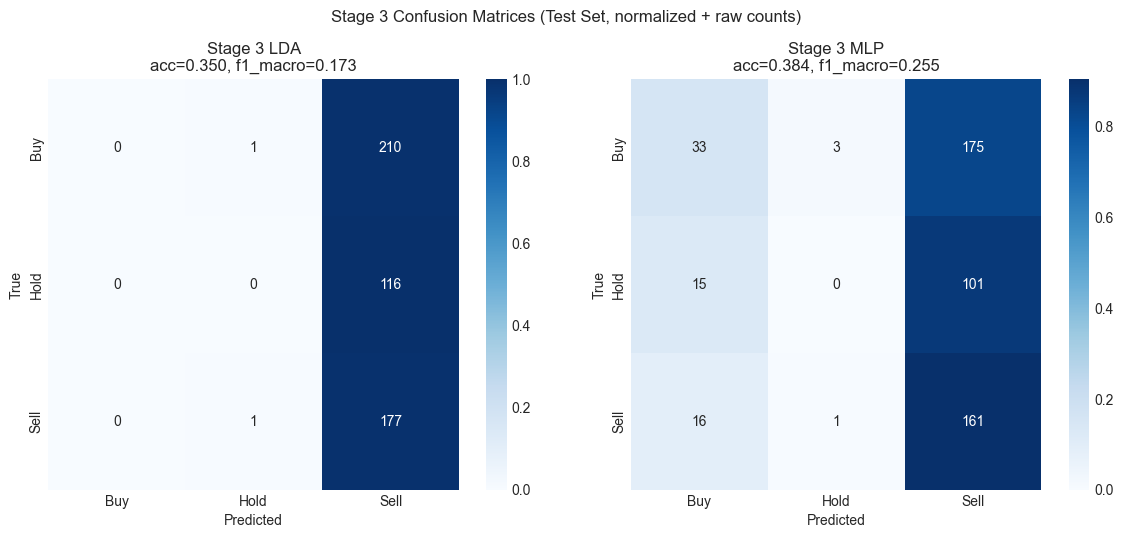

In [3]:
# Stage 3 confusion matrices from test_signals
classes_s3 = ["Buy", "Hold", "Sell"]
y_true = test_signals["y_true"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, model_name in zip(axes, ["LDA", "MLP"]):
    y_pred = test_signals[f"{model_name.lower()}_pred"]
    cm = confusion_matrix(y_true, y_pred, labels=classes_s3)
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=cm, fmt="d", cmap="Blues",
                xticklabels=classes_s3, yticklabels=classes_s3, ax=ax,
                cbar=True, square=True)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    ax.set_title(f"Stage 3 {model_name}\nacc={acc:.3f}, f1_macro={f1:.3f}")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")

plt.suptitle("Stage 3 Confusion Matrices (Test Set, normalized + raw counts)", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "final_confusion_matrices.png", dpi=120, bbox_inches="tight")
plt.show()

## 2. ROC curves (one-vs-rest, per class)

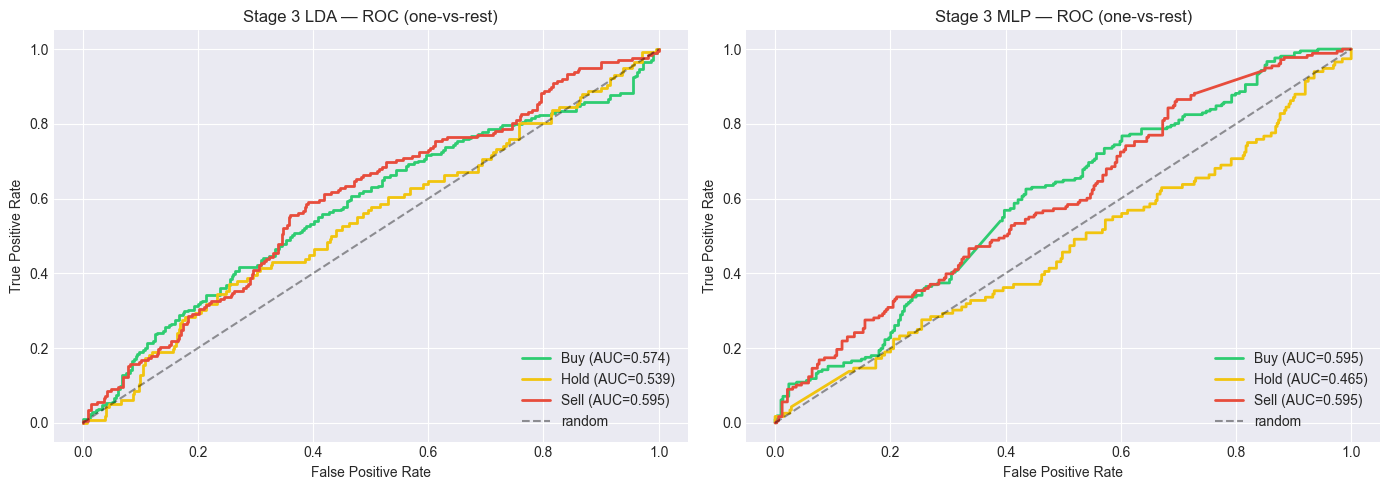

In [4]:
# Build proba arrays from test_signals
y_true_arr = test_signals["y_true"].values
y_bin = label_binarize(y_true_arr, classes=classes_s3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
color_map = {"Buy": "#2ECC71", "Hold": "#F1C40F", "Sell": "#E74C3C"}

for ax, model_name in zip(axes, ["LDA", "MLP"]):
    proba_arr = np.stack([
        test_signals[f"{model_name.lower()}_proba_{c}"].values for c in classes_s3
    ], axis=1)

    for i, cls in enumerate(classes_s3):
        fpr, tpr, _ = roc_curve(y_bin[:, i], proba_arr[:, i])
        auc_val = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color_map[cls], lw=2, label=f"{cls} (AUC={auc_val:.3f})")

    ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="random")
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
    ax.set_title(f"Stage 3 {model_name} — ROC (one-vs-rest)")
    ax.legend(loc="lower right")

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "final_roc_curves.png", dpi=120, bbox_inches="tight")
plt.show()

## 3. Per-class precision/recall/F1 breakdown

In [5]:
for model_name in ["LDA", "MLP"]:
    y_pred = test_signals[f"{model_name.lower()}_pred"]
    print(f"\n=== Stage 3 {model_name} — Classification Report ===")
    print(classification_report(y_true, y_pred, zero_division=0, digits=3))


=== Stage 3 LDA — Classification Report ===
              precision    recall  f1-score   support

         Buy      0.000     0.000     0.000       211
        Hold      0.000     0.000     0.000       116
        Sell      0.352     0.994     0.520       178

    accuracy                          0.350       505
   macro avg      0.117     0.331     0.173       505
weighted avg      0.124     0.350     0.183       505


=== Stage 3 MLP — Classification Report ===
              precision    recall  f1-score   support

         Buy      0.516     0.156     0.240       211
        Hold      0.000     0.000     0.000       116
        Sell      0.368     0.904     0.524       178

    accuracy                          0.384       505
   macro avg      0.295     0.354     0.255       505
weighted avg      0.345     0.384     0.285       505



## 4. Final report-ready summary table

In [6]:
report_summary = pd.DataFrame({
    "Model": ["Stage 1 LDA", "Stage 1 MLP", "Stage 3 LDA", "Stage 3 MLP"],
    "WF F1 (macro)": [stage1_summary.iloc[0]["WF_f1"], stage1_summary.iloc[1]["WF_f1"],
                       stage3_summary.iloc[0]["WF_f1"], stage3_summary.iloc[1]["WF_f1"]],
    "Test Accuracy": [stage1_summary.iloc[0]["test_acc"], stage1_summary.iloc[1]["test_acc"],
                      stage3_summary.iloc[0]["test_acc"], stage3_summary.iloc[1]["test_acc"]],
    "Test F1 (macro)": [stage1_summary.iloc[0]["test_f1"], stage1_summary.iloc[1]["test_f1"],
                        stage3_summary.iloc[0]["test_f1"], stage3_summary.iloc[1]["test_f1"]],
    "Test Balanced Acc": [stage1_summary.iloc[0]["test_balanced_acc"], stage1_summary.iloc[1]["test_balanced_acc"],
                          stage3_summary.iloc[0]["test_balanced_acc"], stage3_summary.iloc[1]["test_balanced_acc"]],
    "Test MCC": [stage1_summary.iloc[0]["test_mcc"], stage1_summary.iloc[1]["test_mcc"],
                 stage3_summary.iloc[0]["test_mcc"], stage3_summary.iloc[1]["test_mcc"]],
}).round(4)
print("=== Final Report-Ready Summary (classification) ===")
print(report_summary.to_string(index=False))

from src.utils.helpers import save_csv
save_csv(report_summary, labels_dir / "final_classification_summary.csv", index=False)

print("\n=== Backtest (Stage 3 only) ===")
print(backtest_summary[["total_return", "sharpe_ratio", "max_drawdown", "n_trades"]].fillna("-").to_string())

print("\nAll output files in data/labels/ and reports/.")

=== Final Report-Ready Summary (classification) ===
      Model  WF F1 (macro)  Test Accuracy  Test F1 (macro)  Test Balanced Acc  Test MCC
Stage 1 LDA         0.5969         0.7036           0.6746             0.6889    0.5739
Stage 1 MLP         0.8911         0.8194           0.8004             0.8379    0.7571
Stage 3 LDA         0.2651         0.3505           0.1733             0.3315   -0.0209
Stage 3 MLP         0.3153         0.3842           0.2545             0.3536    0.0624

=== Backtest (Stage 3 only) ===
                 total_return  sharpe_ratio  max_drawdown  n_trades
strategy                                                           
LDA (with cost)        0.0000        0.0000        0.0000         0
LDA (no cost)          0.0000        0.0000        0.0000         0
MLP (with cost)        0.1582        0.5531       -0.1585        26
MLP (no cost)          0.1582        0.5531       -0.1585        26
Buy & Hold             0.4376        0.6653       -0.3215         1

## Checkpoint #5 — final eval ve sunum hazırlığı

Bu noktada MVP'nin sayısal tarafı bitmiş olur. Notebook çıktıları + reports/ altındaki PNG'ler final raporun temel kaynağı.

### Final report'a yansıtılacak (LaTeX IEEE template, 6-12 sayfa)
- Abstract (150-250 kelime, geçmiş zaman): metrik özeti
- Introduction + Lit review (10+ ref): trading ML, hierarchical models, regime detection (Hizir Lit review FAZ 7'de yapacak)
- Materials & Methods: hierarchical Bayesian formulation, LDA discriminant function, MLP softmax+CE, GMM mixture model, walk-forward + OOF mantığı
- Experimental Setup: train-test %85-15, walk-forward (3 ay step MVP), Optuna (10-12 trial), random_state=42
- Results: bu notebook'un tüm çıktıları (CM, ROC, PCA decision boundary, equity curve, summary table)
- Conclusion: en iyi model + neden + limitations + future work (2. iter scope)